# Numerical Integration: Simpson’s 3/8 Rule
---
## Introduction
Simpson’s 3/8 Rule is a numerical integration method based on cubic interpolation.

It requires the number of subintervals (n) to be a multiple of 3.

For a function f(x) over [a, b]:

$$h = \frac{b-a}{n}$$

### Simpson’s 3/8 Rule Formula

$$
\int_a^b f(x) dx \approx \frac{3h}{8} \left[
f(x_0) + 3\sum f(x_{3k+1}) + 3\sum f(x_{3k+2}) + 2\sum f(x_{3k}) + f(x_n)
\right]
$$
Where n must be divisible by 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simpson_38_rule(f, a, b, n):
    if n % 3 != 0:
        raise ValueError('n must be a multiple of 3 for Simpson’s 3/8 Rule')

    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    S = y[0] + y[n]

    for i in range(1, n):
        if i % 3 == 0:
            S += 2 * y[i]
        else:
            S += 3 * y[i]

    return (3*h/8) * S

## Level 1 (Basic)
Approximate:

$$\int_0^3 x^3 dx$$
Exact value = 81/4

In [3]:
def f1(x):
    return x**3

a = 0
b = 3
n = 6  # multiple of 3

approx1 = simpson_38_rule(f1, a, b, n)
exact1 = 81/4

approx1, exact1

(20.25, 20.25)

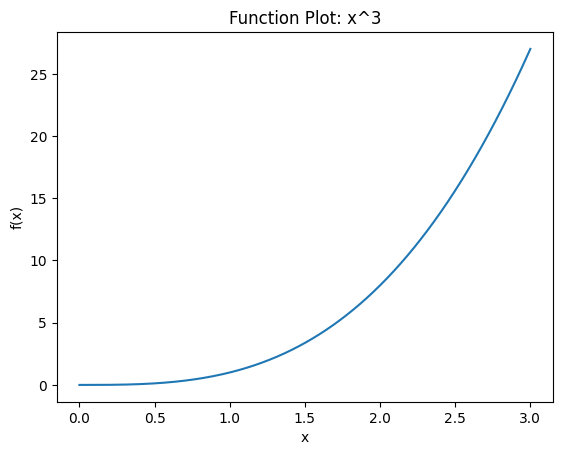

In [4]:
x = np.linspace(a, b, 400)
y = f1(x)

plt.figure()
plt.plot(x, y)
plt.title('Function Plot: x^3')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

## Level 2 (Intermediate)
Approximate:
\[
\int_0^2 e^{-x^2} dx
\]

In [5]:
def f2(x):
    return np.exp(-x**2)

a = 0
b = 2
n = 9  # multiple of 3

approx2 = simpson_38_rule(f2, a, b, n)
approx2

0.8820592184216159

## Level 3 (Advanced)
Perform convergence study for:
\[
\int_1^4 \ln(x) dx
\]
Compare approximation for n = 3, 6, 9, 12.
Exact value = [x ln(x) - x]_1^4

In [6]:
def f3(x):
    return np.log(x)

def exact_value():
    return (4*np.log(4)-4) - (1*np.log(1)-1)

a = 1
b = 4

for n in [3, 6, 9, 12]:
    approx = simpson_38_rule(f3, a, b, n)
    print('n =', n, 'Approximation =', approx)

print('Exact =', exact_value())

n = 3 Approximation = 2.535589788301521
n = 6 Approximation = 2.5441572116930558
n = 9 Approximation = 2.544935636724337
n = 12 Approximation = 2.5450942114210418
Exact = 2.5451774444795623
